In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## FILE READING 

In [75]:
def readfile():
    df=pd.read_csv("C:/Users/DHARSHINI/Downloads/sem5/machine-learning/experiment5/wdbc.data",header=None)
    print(df.head())
    data_inspect(df)

## DATA STRUCTURE INSPECT 

In [76]:
def data_inspect_visual(df):
    cols=df.select_dtypes(include=['int64','float64']).columns
    for i in cols:
        plt.figure(figsize=(5,5))
        df[i].hist(bins=20)
        plt.xlabel(i)
        plt.ylabel("Frequency")
        plt.show()

In [77]:
def data_inspect(df):
    print("SIZE:",df.size)
    print("\n\nCOLUMNS\n ",df.columns)
    print("\n\nDATA TYPES\n ",df.dtypes)
    print("\n\nDESCRIBE\n",df.describe())
    print("\n\nINFO\n",df.info())
    data_inspect_visual(df)
    missing_values(df)
    return

## MISSING VALUES 

In [78]:
def missingvalues_heat_map(df):
    plt.figure(figsize=(5,5))
    sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
    plt.title("\MISSING VALUES ")
    plt.show()

In [79]:
def missing_values(df):
    print("\n\nNULL VALUES\n",df.isnull().sum())
    print("\n\nNULL VALUES PERCENTAGE\n",(df.isnull().sum()/len(df))*100)

    missingvalues_heat_map(df)
    duplicate_values(df)

## DUPLICATE VALUES

In [80]:
def duplicate_values(df):
    duplicate=df.duplicated().sum()
    print("\n\nDUPLICATES VALUES ",duplicate)
    if(duplicate>0):
        df=df.drop_duplicates()
        print("\nAfter Removing Duplicates : ",df.duplicated().sum())
    print("Calling categorical_features...")
    categorical_features(df)
    return df

## CATEGORICAL FEATURE PROFILING 

In [81]:
def value_count_plot(df,col):

    plt.figure(figsize=(5,5))
    sns.countplot(data=df[col])
    plt.title("VALUE COUNT PLOT ")
    plt.show()


In [82]:
def categorical_features(df):
    cate=df.select_dtypes(include='object').columns

    for col in cate:
        print("UNIQUE VALUES IN THE ",col,": ",df[col].unique())
        value_count_plot(df,col)
    numerical_feature_analysis(df)


## NUMERICAL FEATURE PROFILING 

In [83]:
def numerical_feature_analysis(df):
    cols=df.select_dtypes(include=['int64','float64']).columns
    print("\n\nDESCRIBE\n",df.describe())

    print("\n\nSKEWNESS")
    for i in cols:
        print(f"{i}:{df[i].skew()}")

    linear_correlation(df)

## CORRELATION ANALYSIS

In [84]:
def linear_correlation(df):
    plt.figure(figsize=(18,18))
    sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
    plt.title("LINEAR CORRELATION")
    plt.show()

    outliers(df)

## OUTLIERS VISUALS

In [85]:
def outliers(df):
    print("OUTLIERS VISUALS")
    cate=df.select_dtypes(include="number").columns
    for col in cate:
        plt.figure(figsize=(5,5))
        plt.boxplot(x=df[col])
        plt.xlabel(col)
        plt.show()

         0  1      2      3       4       5        6        7       8   \
0    842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001   
1    842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869   
2  84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974   
3  84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414   
4  84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980   

        9   ...     22     23      24      25      26      27      28      29  \
0  0.14710  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.07017  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.12790  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.10520  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.10430  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       30       31  
0  0.4601  0.11890  
1  0.2750  0.08902  
2  0.

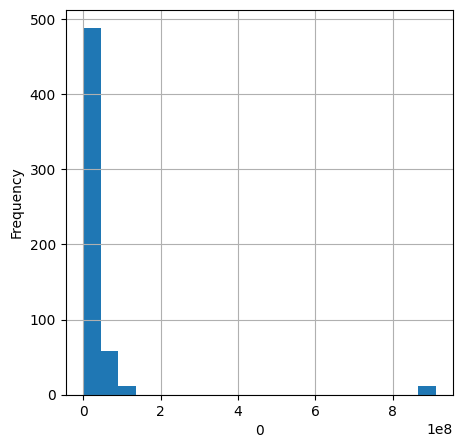

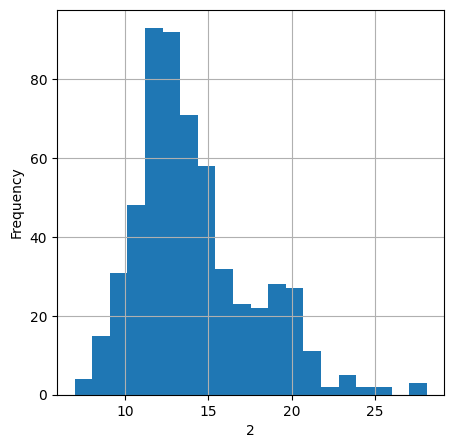

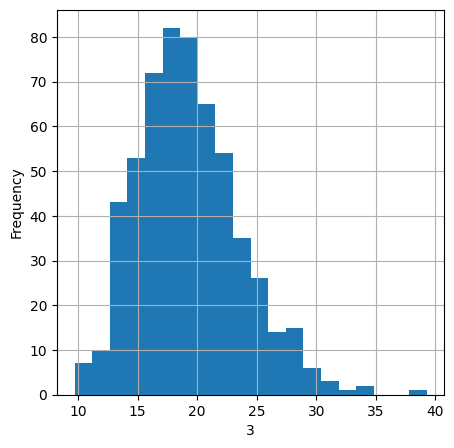

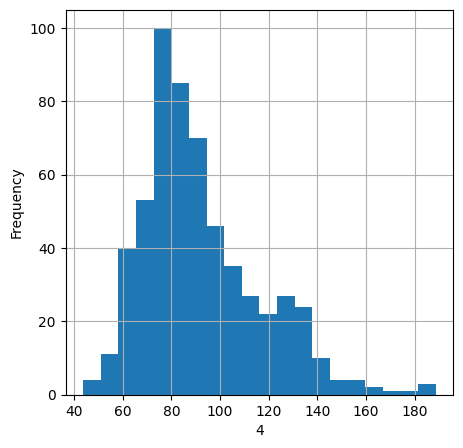

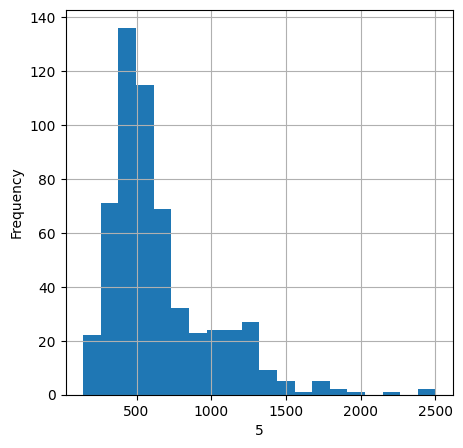

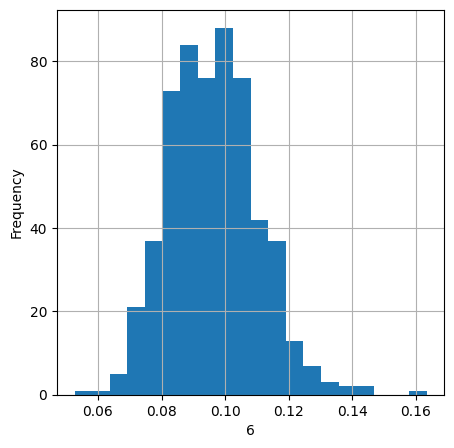

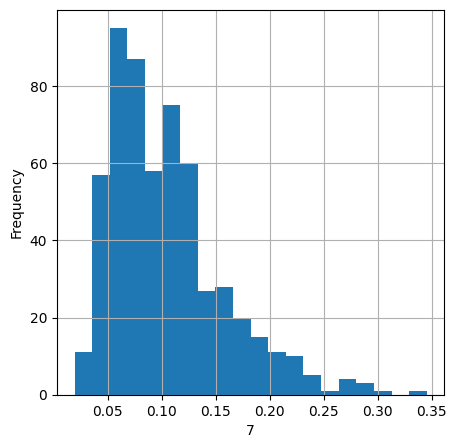

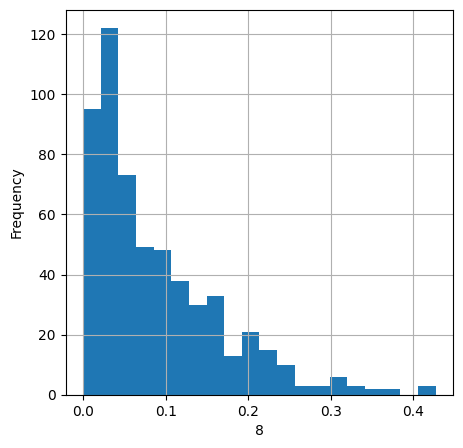

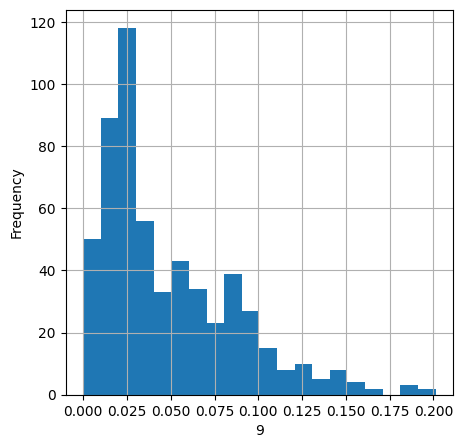

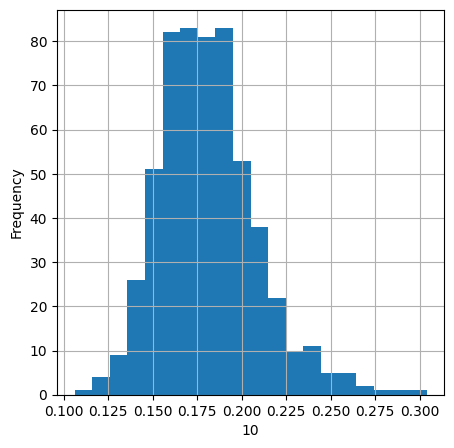

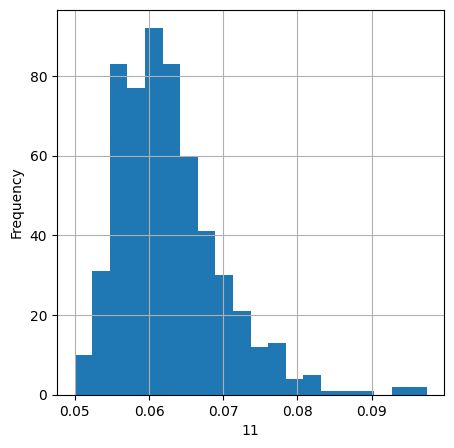

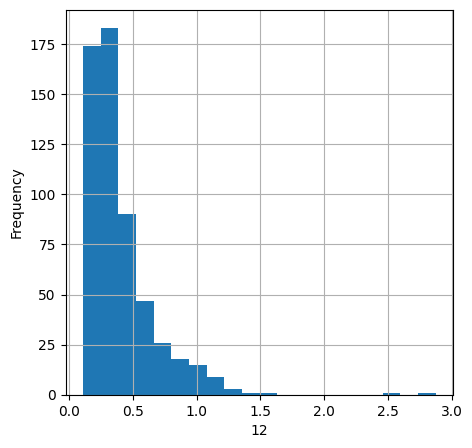

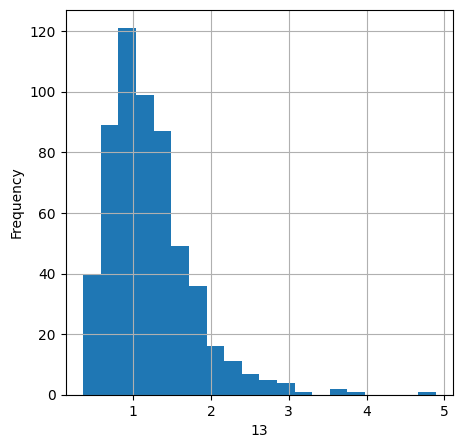

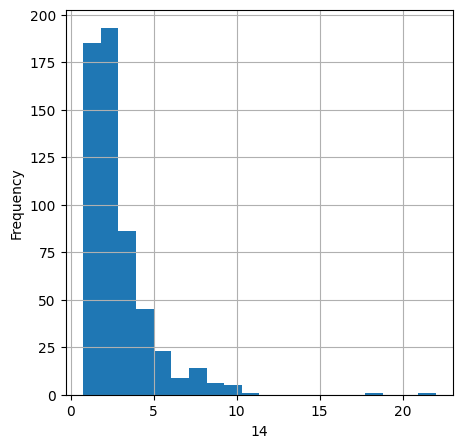

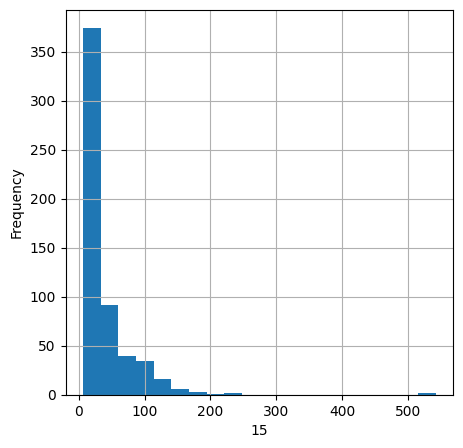

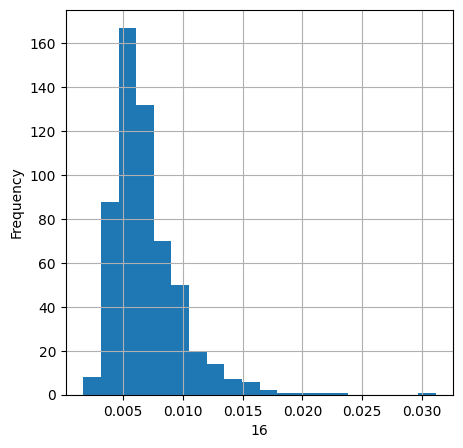

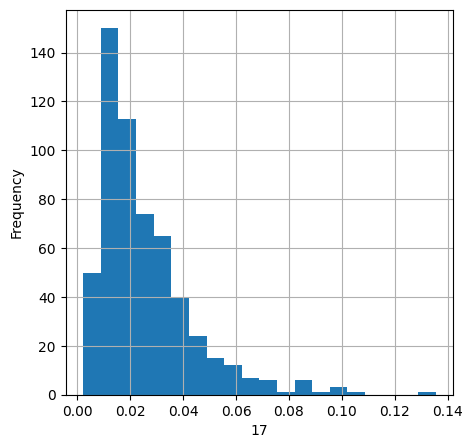

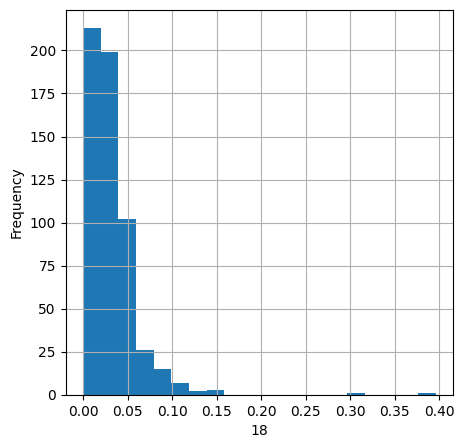

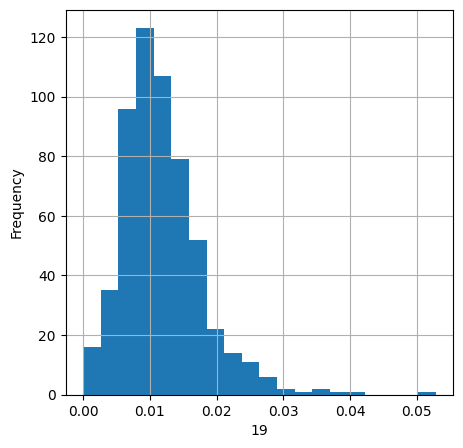

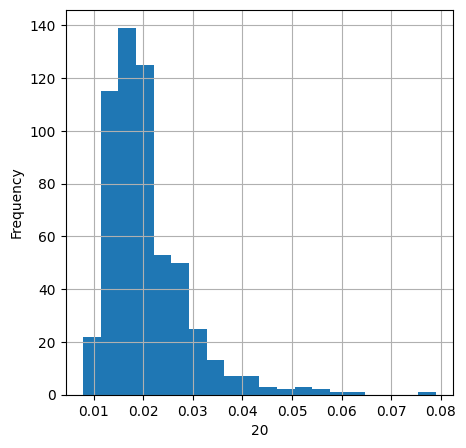

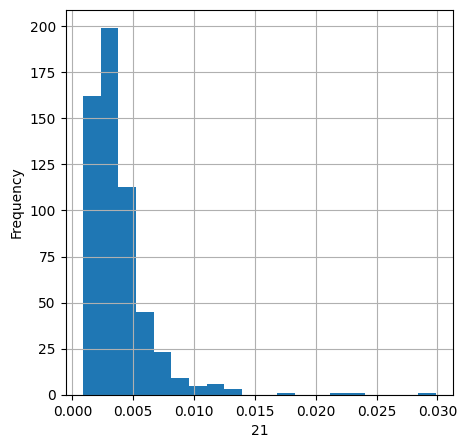

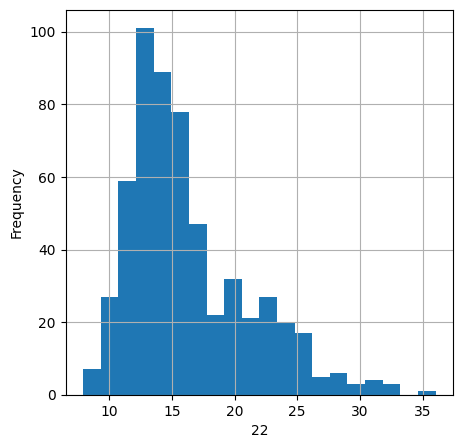

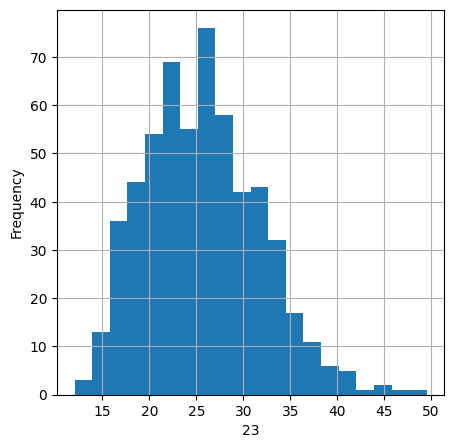

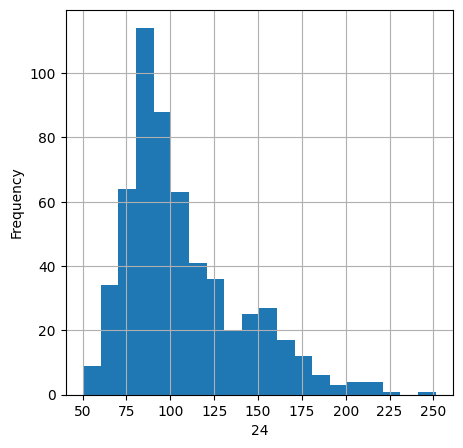

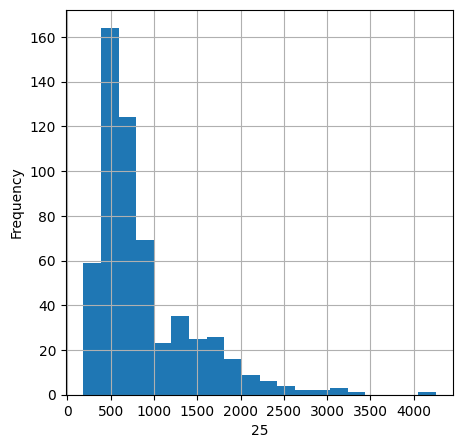

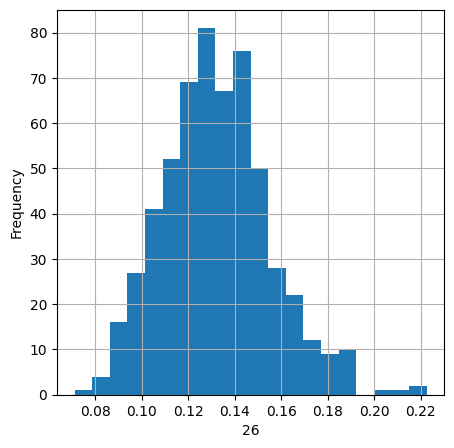

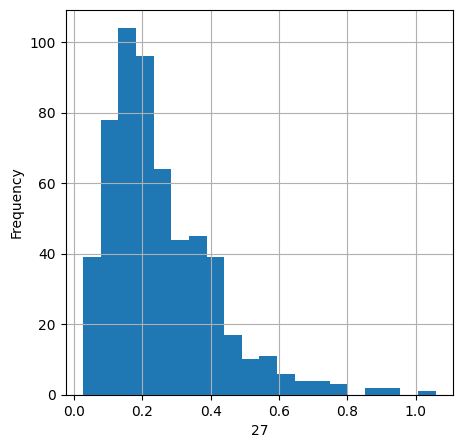

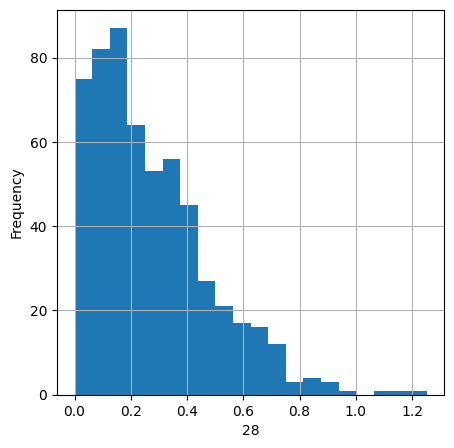

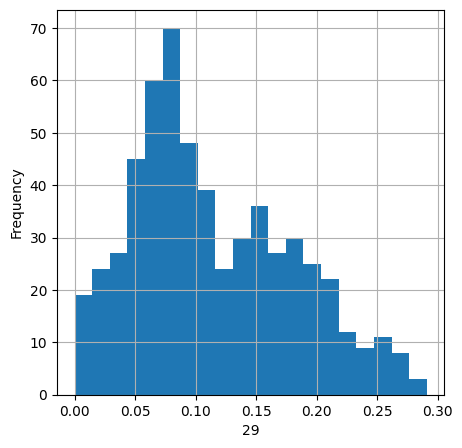

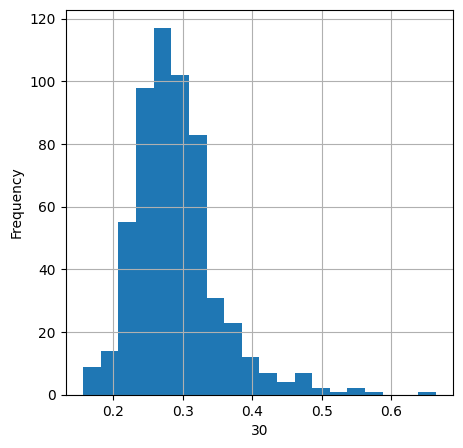

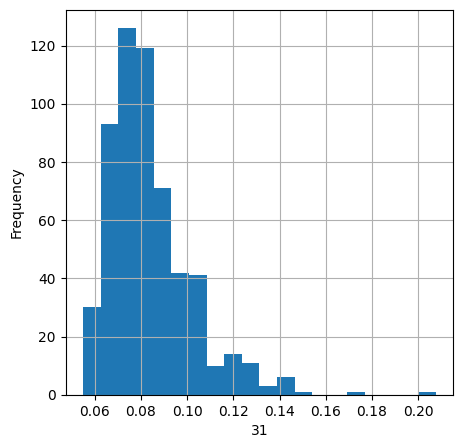



NULL VALUES
 0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
dtype: int64


NULL VALUES PERCENTAGE
 0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    0.0
16    0.0
17    0.0
18    0.0
19    0.0
20    0.0
21    0.0
22    0.0
23    0.0
24    0.0
25    0.0
26    0.0
27    0.0
28    0.0
29    0.0
30    0.0
31    0.0
dtype: float64


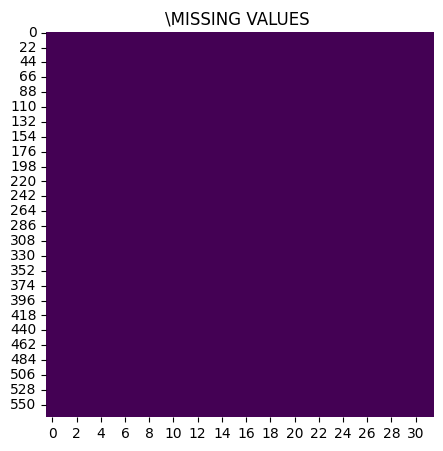



DUPLICATES VALUES  0
Calling categorical_features...
UNIQUE VALUES IN THE  1 :  ['M' 'B']


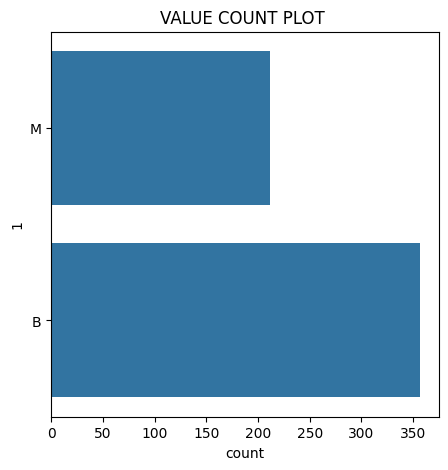



DESCRIBE
                  0           2           3           4            5   \
count  5.690000e+02  569.000000  569.000000  569.000000   569.000000   
mean   3.037183e+07   14.127292   19.289649   91.969033   654.889104   
std    1.250206e+08    3.524049    4.301036   24.298981   351.914129   
min    8.670000e+03    6.981000    9.710000   43.790000   143.500000   
25%    8.692180e+05   11.700000   16.170000   75.170000   420.300000   
50%    9.060240e+05   13.370000   18.840000   86.240000   551.100000   
75%    8.813129e+06   15.780000   21.800000  104.100000   782.700000   
max    9.113205e+08   28.110000   39.280000  188.500000  2501.000000   

               6           7           8           9           10  ...  \
count  569.000000  569.000000  569.000000  569.000000  569.000000  ...   
mean     0.096360    0.104341    0.088799    0.048919    0.181162  ...   
std      0.014064    0.052813    0.079720    0.038803    0.027414  ...   
min      0.052630    0.019380    0.000000  

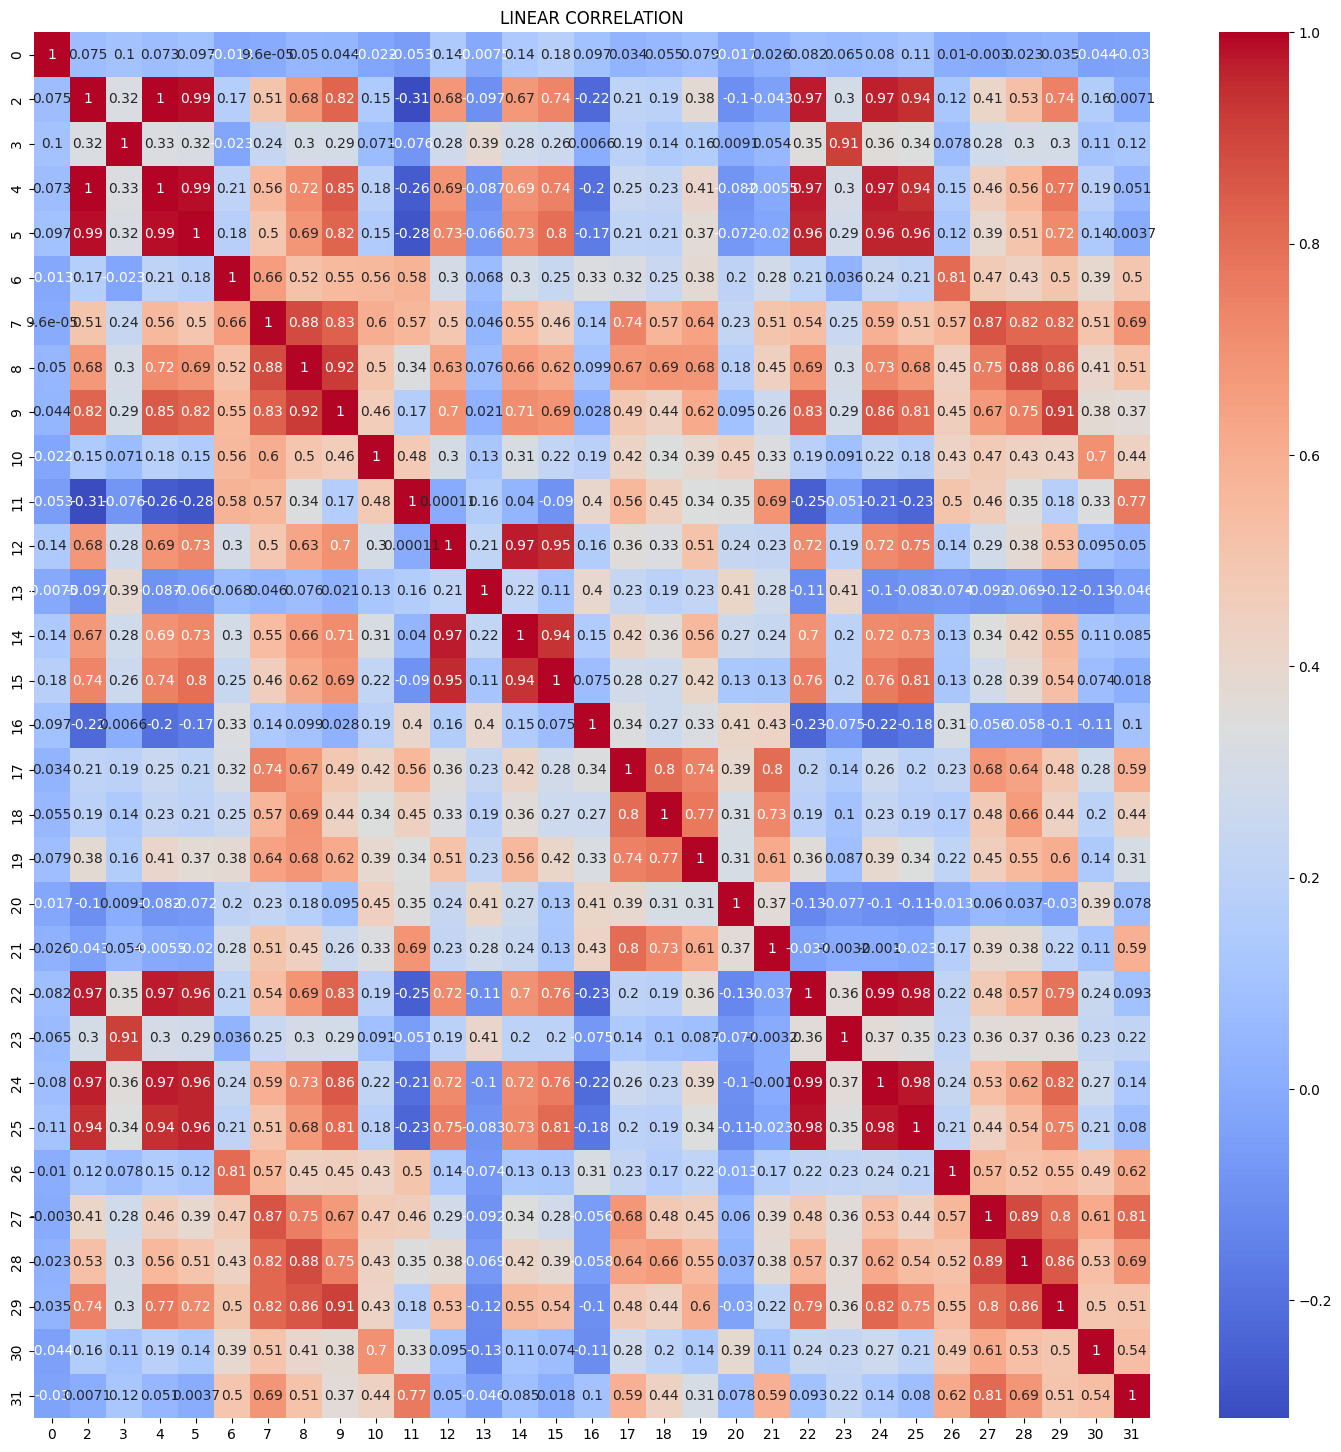

OUTLIERS VISUALS


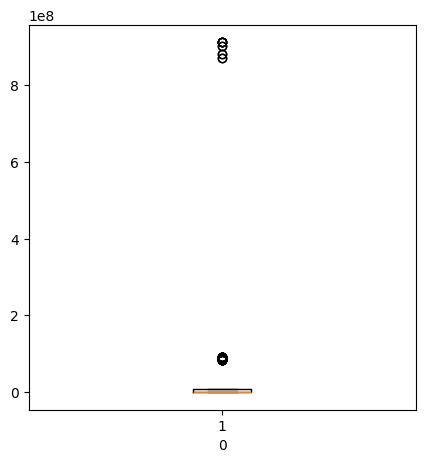

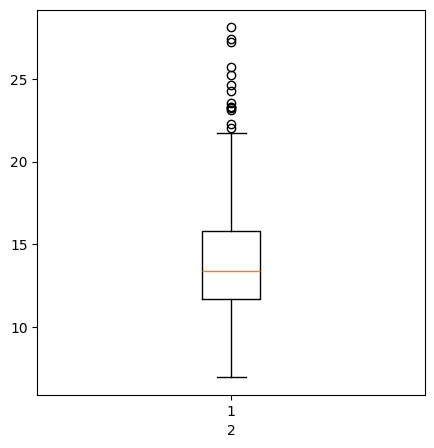

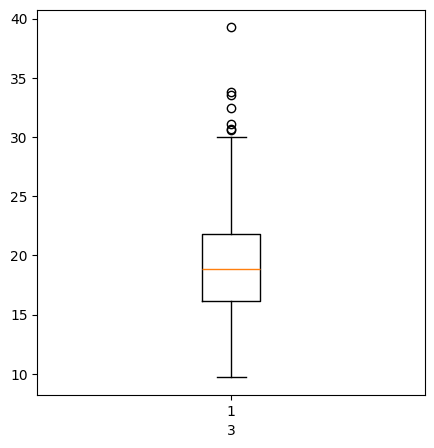

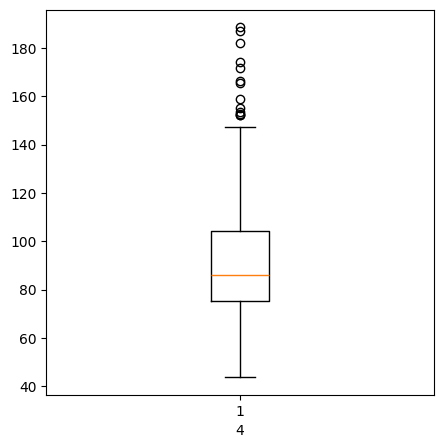

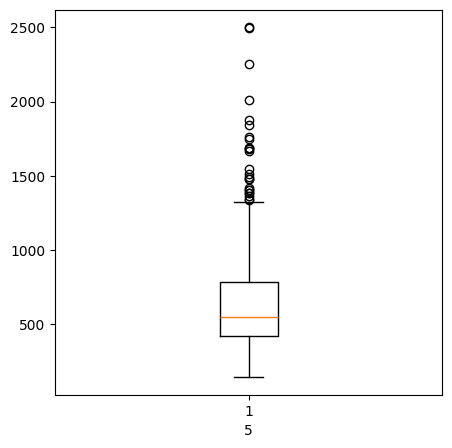

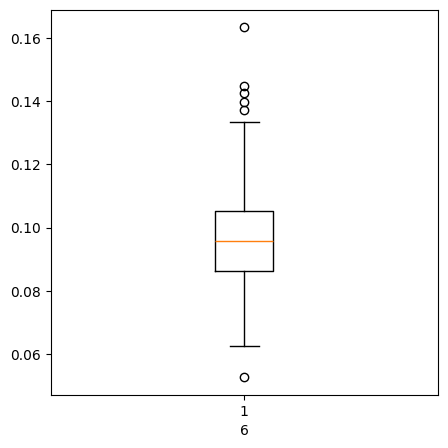

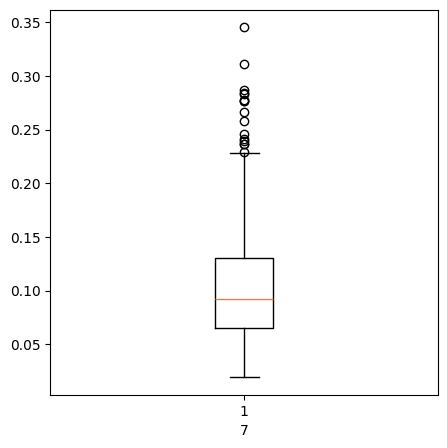

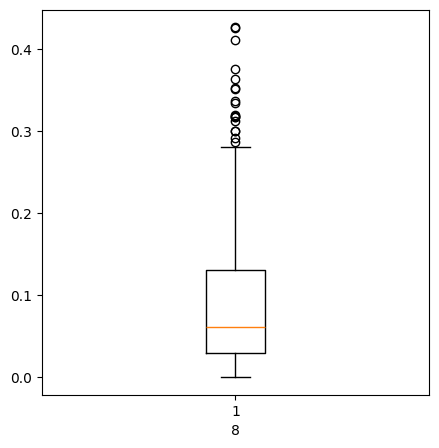

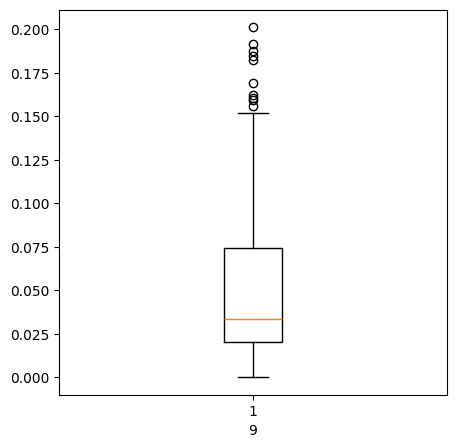

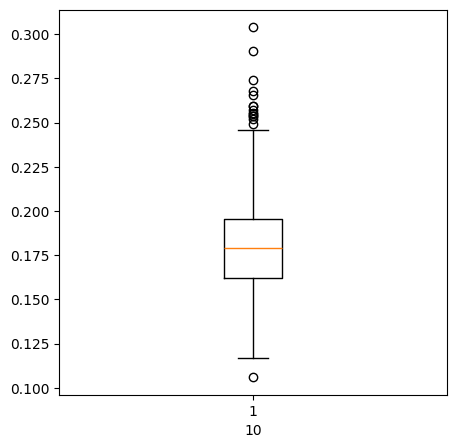

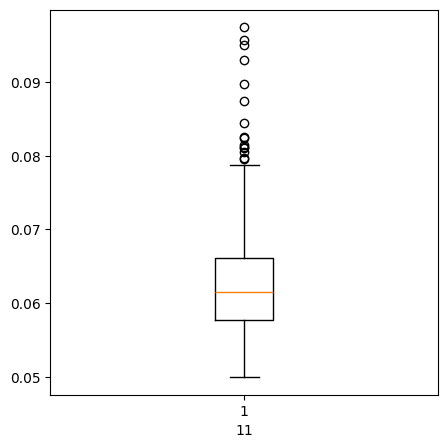

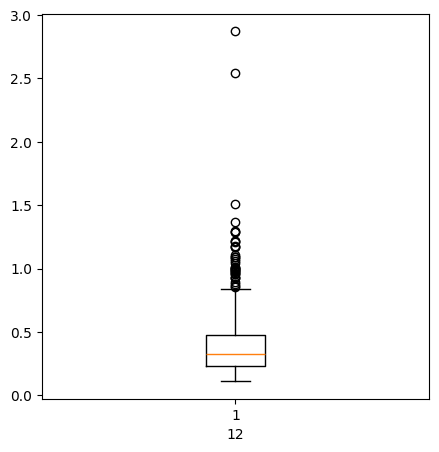

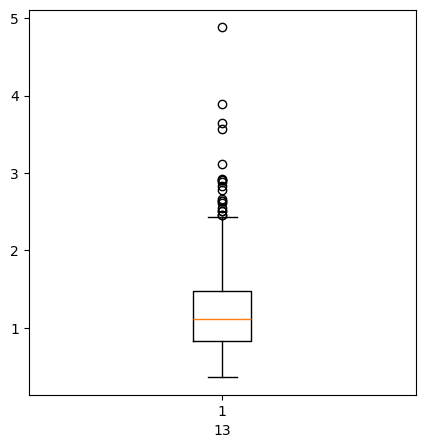

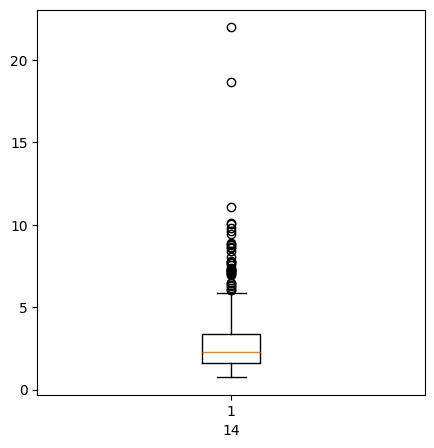

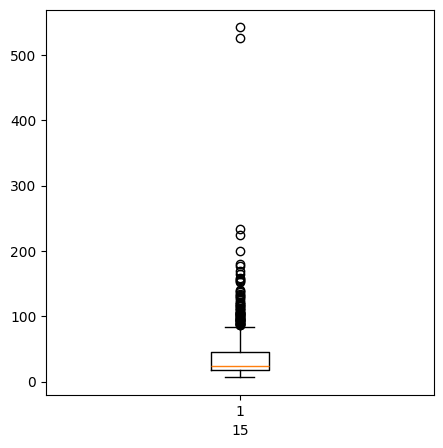

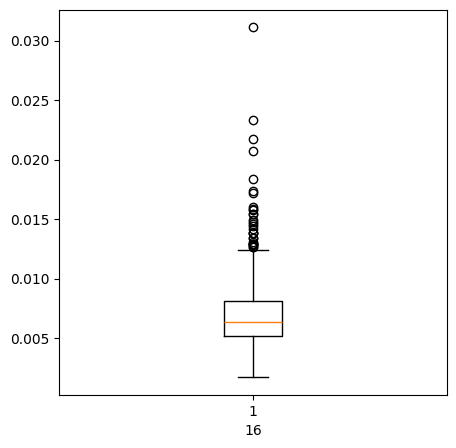

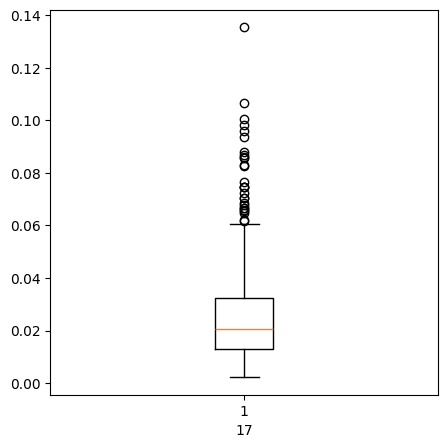

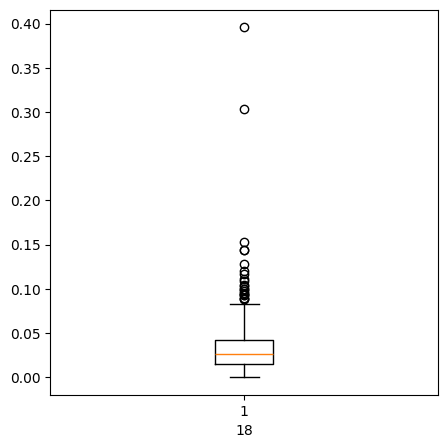

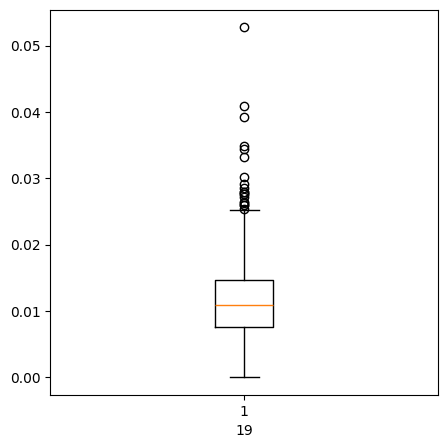

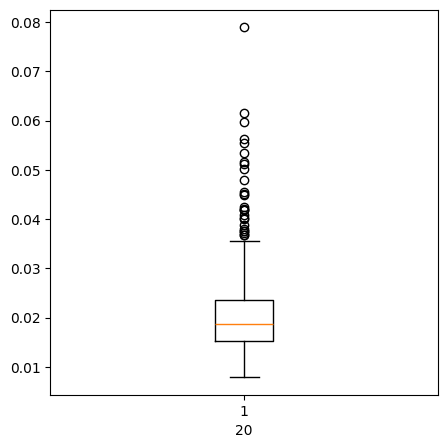

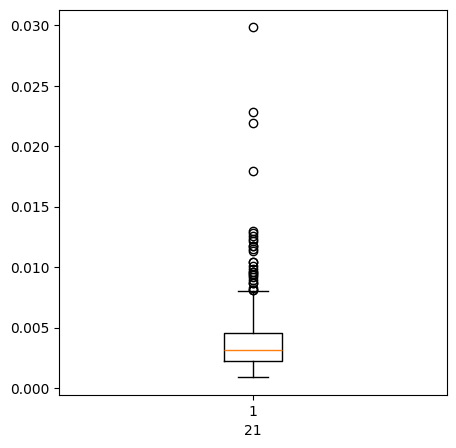

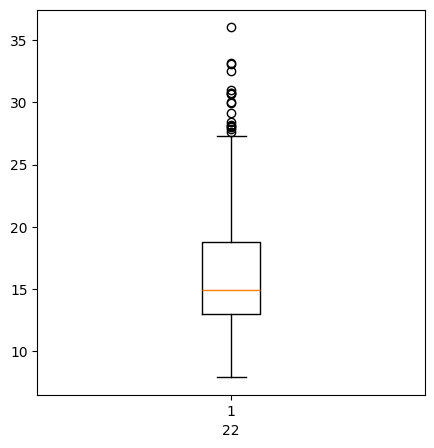

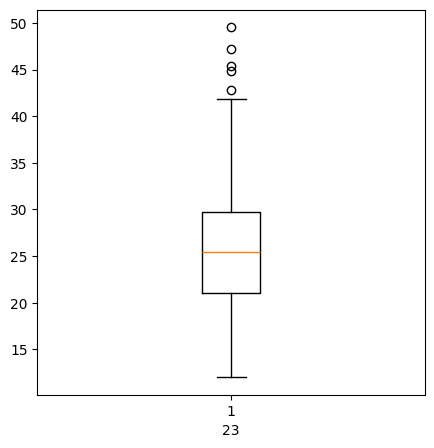

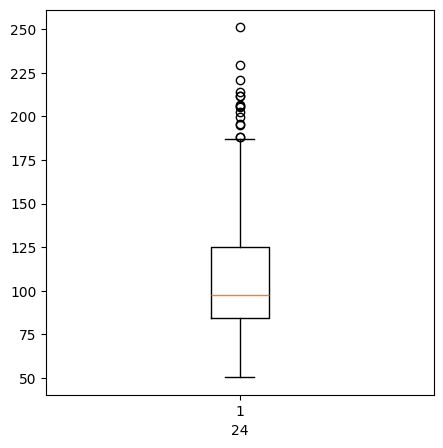

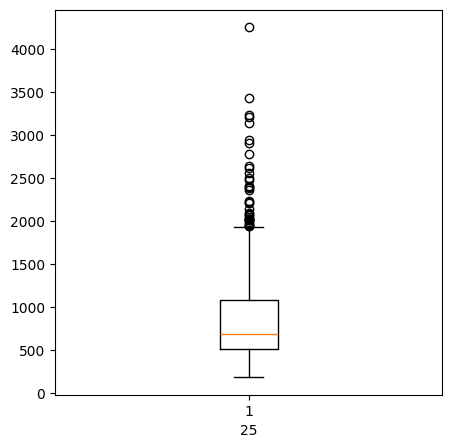

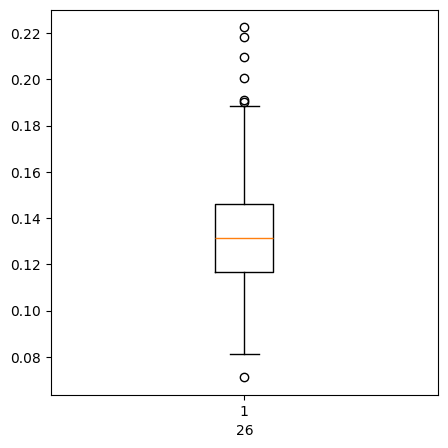

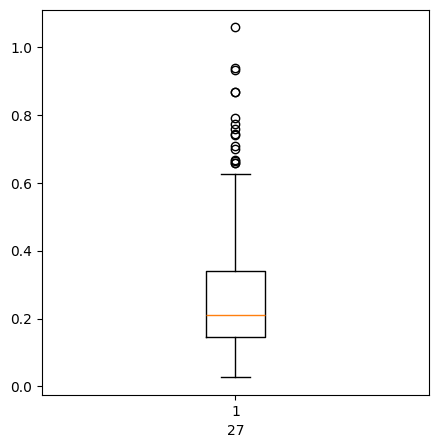

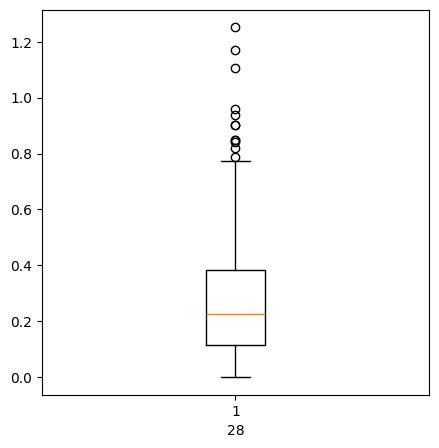

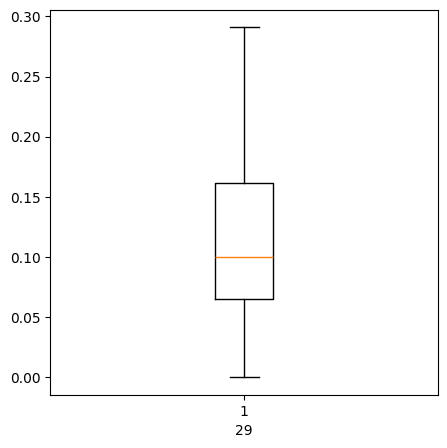

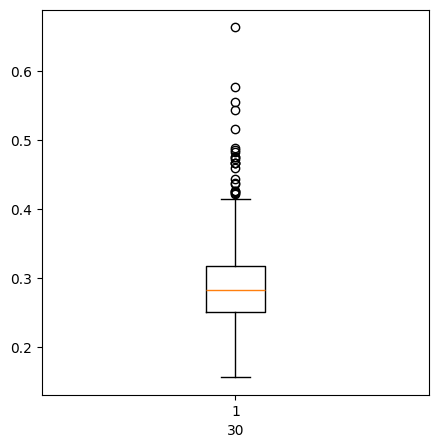

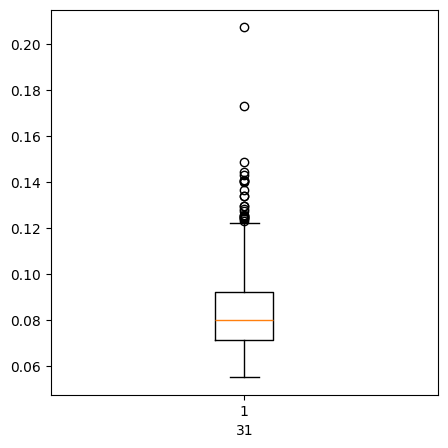

In [86]:
readfile()